# Exploración del precio Brent y el riesgo geopolítico

## 1. Objetivo

Analizar la evolución mensual del precio del petróleo Brent y su posible relación con el riesgo geopolítico. 

## 2. Importación de librerías

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent

DATA_FILE = ROOT / "data" / "processed" / "brent_gpr_monthly.csv"

## 3. Carga del dataset procesado

Leemos directamente el CSV generado por el notebook de preprocesamiento. Aquí no se repiten la limpieza ni la unión de los archivos originales.

In [2]:
df = pd.read_csv(DATA_FILE)
df["month"] = pd.to_datetime(df["month"], format="%Y-%m")

print("Primeras filas:")
display(df.head())
print("Últimas filas:")
display(df.tail())

Primeras filas:


,month,brent_price,GPR,GPRT,GPRA,brent_price_next_month
0,1987-05-01,18.58,98.650917,97.371407,95.235184,18.86
1,1987-06-01,18.86,94.182404,99.829254,81.829407,19.86
2,1987-07-01,19.86,98.871964,107.528946,88.264816,18.98
3,1987-08-01,18.98,99.968445,115.480316,87.601334,18.31
4,1987-09-01,18.31,121.167076,143.451981,97.539818,18.76


Últimas filas:


,month,brent_price,GPR,GPRT,GPRA,brent_price_next_month
466,2026-03-01,103.13,330.176819,319.203979,450.360352,117.29
467,2026-04-01,117.29,250.283661,268.601074,305.941193,107.14
468,2026-05-01,107.14,203.581985,233.492905,215.246140,85.40
469,2026-06-01,85.40,179.941696,214.942444,184.833160,83.76
470,2026-07-01,83.76,167.532242,190.894791,180.699921,91.08


In [3]:
print("Dimensiones:", df.shape)
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Período:", df["month"].min(), "a", df["month"].max())
print("Meses duplicados:", df["month"].duplicated().sum())
print()
print("Valores faltantes:")
display(df.isna().sum().to_frame("faltantes"))

Dimensiones: (471, 6)

Tipos de datos:
month                     datetime64[us]
brent_price                      float64
GPR                              float64
GPRT                             float64
GPRA                             float64
brent_price_next_month           float64
dtype: object

Período: 1987-05-01 00:00:00 a 2026-07-01 00:00:00
Meses duplicados: 0

Valores faltantes:


,faltantes
month,0
brent_price,0
GPR,0
GPRT,0
GPRA,0
brent_price_next_month,0


## 4. Variables disponibles

| Variable | Descripción |
|---|---|
| `month` | Mes de la observación. |
| `brent_price` | Precio promedio mensual del Brent. |
| `GPR` | Riesgo geopolítico general. |
| `GPRT` | Amenazas geopolíticas. |
| `GPRA` | Actos geopolíticos efectivos. |
| `brent_price_next_month` | Precio promedio del Brent del mes siguiente. |

## 5. Estadísticas descriptivas

`describe()` resume la cantidad de observaciones, el promedio, la dispersión y los principales percentiles.

In [4]:
df.describe().round(2)

,month,brent_price,GPR,GPRT,GPRA,brent_price_next_month
count,471,471.00,471.00,471.00,471.00,471.00
mean,2006-11-30 23:44:42.802547,51.42,104.11,107.38,102.02,51.57
min,1987-05-01 00:00:00,9.82,39.05,36.69,28.45,9.82
25%,1997-02-15 00:00:00,19.48,79.42,78.83,66.72,19.56
50%,2006-12-01 00:00:00,46.52,91.93,95.61,84.10,46.54
75%,2016-09-16 00:00:00,74.80,113.35,122.95,109.26,75.00
max,2026-07-01 00:00:00,132.72,512.53,403.71,854.07,132.72
std,NaN,32.81,50.53,48.43,77.14,32.82


El Brent tiene un promedio cercano a **51,42 USD por barril**, con un mínimo de **9,82** y un máximo de **132,72**. El GPR promedia aproximadamente **104,11** y su desvío estándar es cercano a **50,53**.

## 6. Acontecimientos de referencia

Las líneas verticales ayudan a ubicar conflictos dentro de las series. Se muestran solamente los acontecimientos comprendidos en el período del dataset y se alterna la altura de sus etiquetas.

El cierre del estrecho de Ormuz ocurrió el **28 de febrero de 2026**. Como los datos son mensuales, su posible impacto puede observarse principalmente desde marzo de 2026. 

In [5]:
eventos = {
    "Invasión de Kuwait": "1990-08-01",
    "Guerra del Golfo": "1991-01-01",
    "Atentados del 11-S": "2001-09-01",
    "Guerra de Irak": "2003-03-01",
    "Crisis Rusia-Ucrania": "2014-03-01",
    "Invasión rusa de Ucrania": "2022-02-01",
    "Invasión Israel a Palestina": "2023-10-27",
    "Cierre del estrecho de Ormuz": "2026-02-28",
}

eventos = {nombre: pd.to_datetime(fecha) for nombre, fecha in eventos.items()}
fin_ultimo_mes = df["month"].max() + pd.offsets.MonthEnd(1)
eventos_periodo = {
    nombre: fecha
    for nombre, fecha in eventos.items()
    if df["month"].min() <= fecha <= fin_ultimo_mes
}

def marcar_eventos(ax, etiquetas=True):
    for i, (nombre, fecha) in enumerate(eventos_periodo.items()):
        ax.axvline(fecha, color="black", linestyle="--", alpha=0.45)
        if etiquetas:
            ax.text(
                fecha,
                0.98 if i % 2 == 0 else 0.72,
                nombre,
                transform=ax.get_xaxis_transform(),
                rotation=90,
                va="top",
                ha="right",
                fontsize=8,
            )

print("Eventos incluidos:", len(eventos_periodo))

Eventos incluidos: 8


## 7. Evolución temporal

### 7.1. Precio mensual del Brent

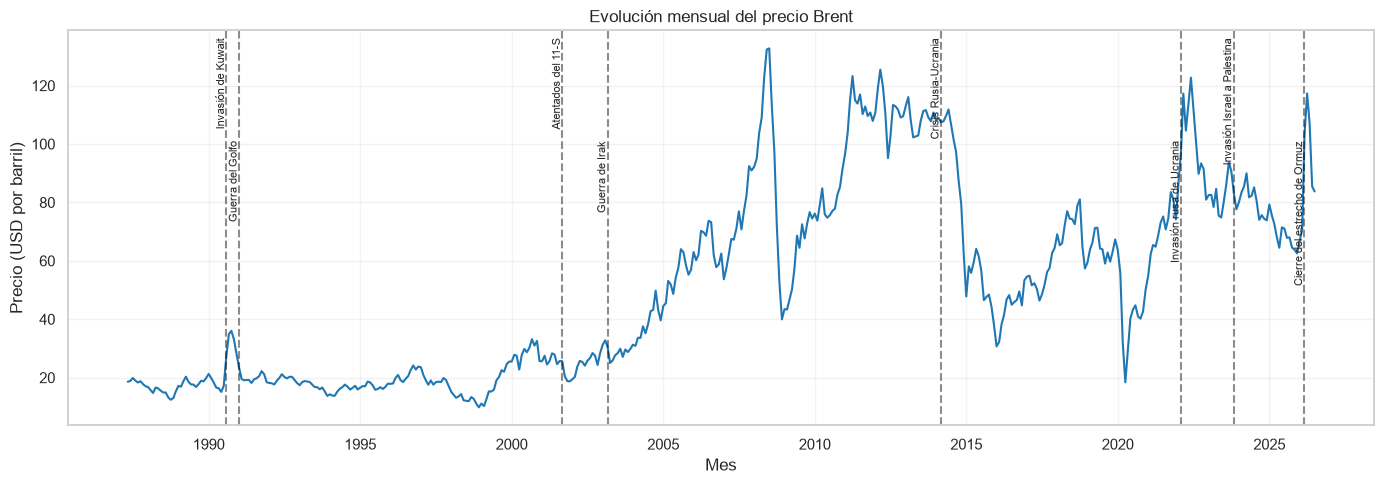

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=df, x="month", y="brent_price", ax=ax, color="#1f77b4")
marcar_eventos(ax)
ax.set_title("Evolución mensual del precio Brent")
ax.set_xlabel("Mes")
ax.set_ylabel("Precio (USD por barril)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

El precio presenta ciclos, subas y caídas marcadas. Algunos acontecimientos coinciden con cambios visibles, pero el gráfico no permite atribuirles causalidad.

### 7.2. Riesgo geopolítico general

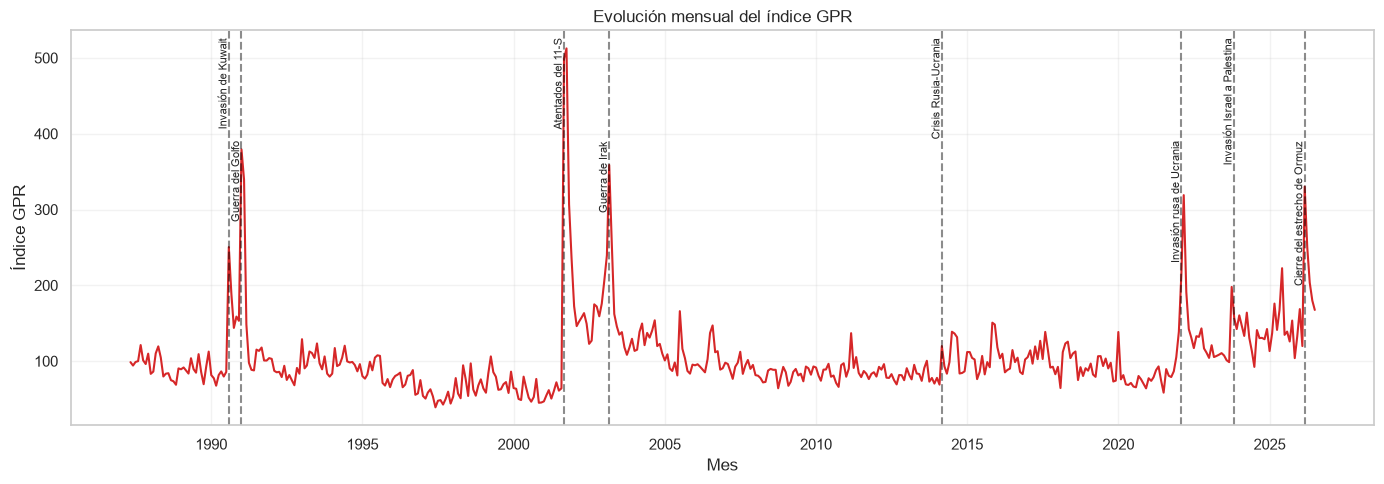

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=df, x="month", y="GPR", ax=ax, color="#d62728")
marcar_eventos(ax)
ax.set_title("Evolución mensual del índice GPR")
ax.set_xlabel("Mes")
ax.set_ylabel("Índice GPR")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

El GPR presenta picos puntuales. Varios ocurren cerca de conflictos seleccionados, aunque también existen cambios fuera de esas fechas.

### 7.3. Amenazas y actos geopolíticos

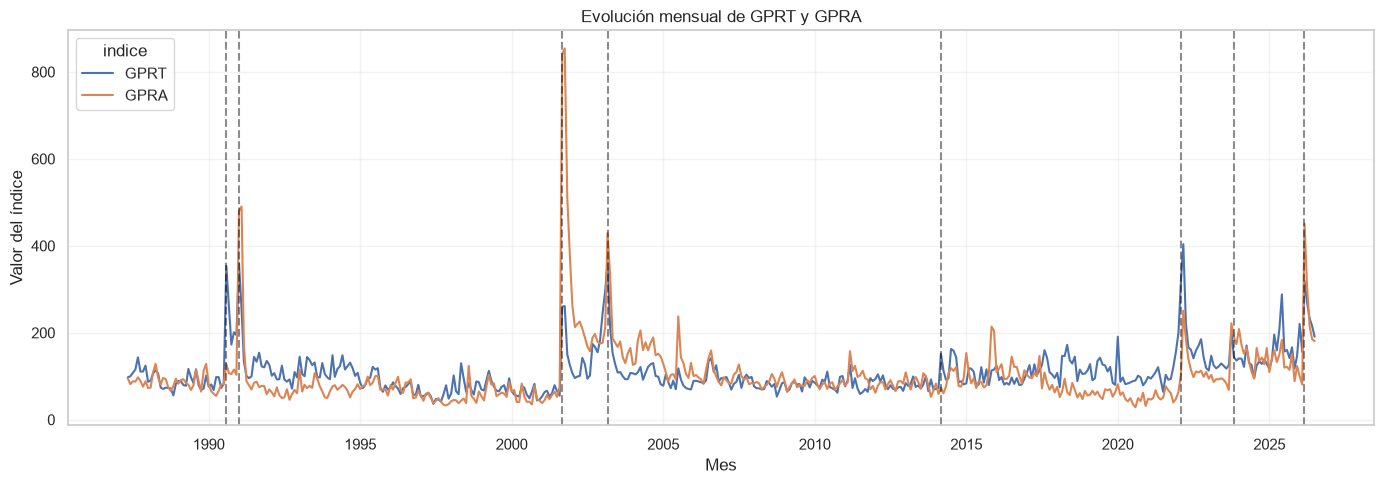

In [8]:
gpr_components = df.melt(
    id_vars="month",
    value_vars=["GPRT", "GPRA"],
    var_name="indice",
    value_name="valor",
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=gpr_components, x="month", y="valor", hue="indice", ax=ax)
marcar_eventos(ax, etiquetas=False)
ax.set_title("Evolución mensual de GPRT y GPRA")
ax.set_xlabel("Mes")
ax.set_ylabel("Valor del índice")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

`GPRT` y `GPRA` se relacionan, pero sus picos no siempre tienen la misma intensidad porque distinguen amenazas de actos efectivos.

### 7.4. Brent y GPR alineados

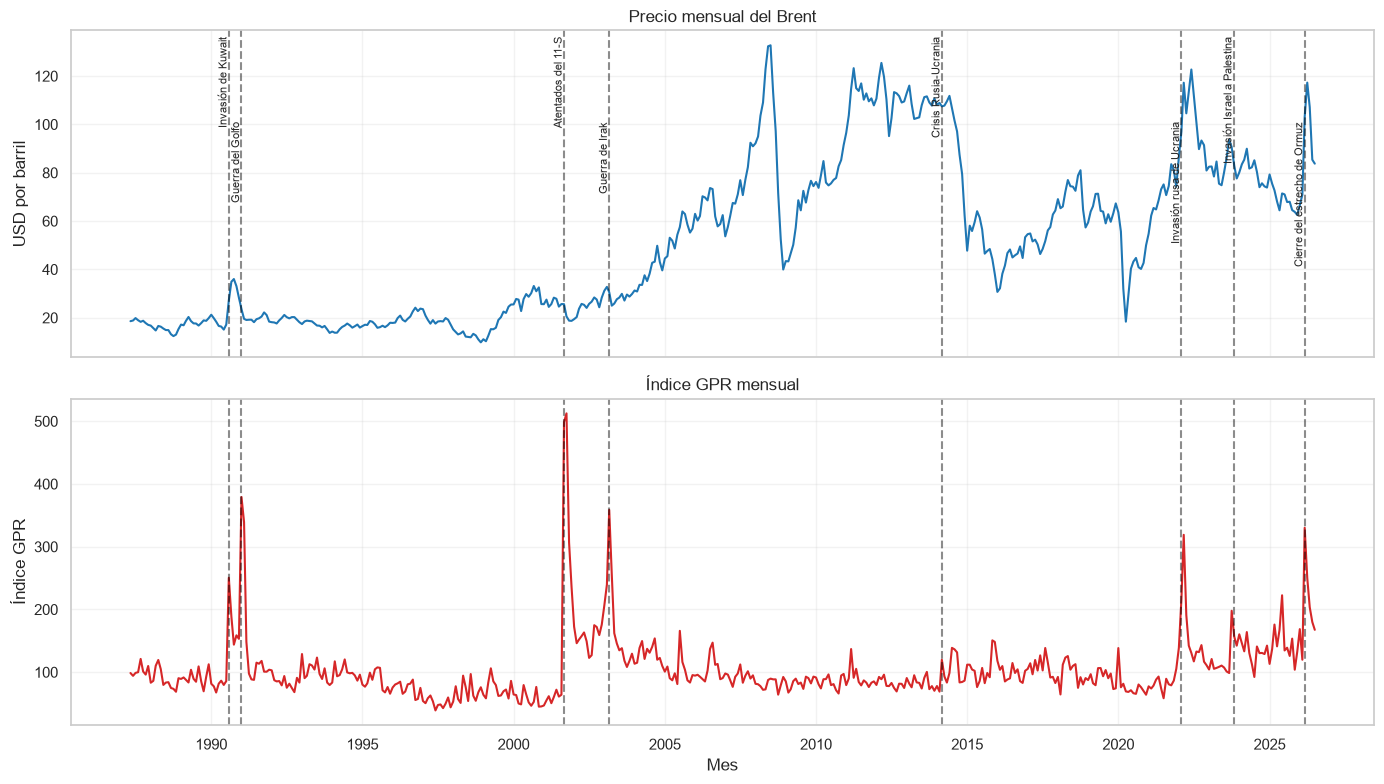

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sns.lineplot(data=df, x="month", y="brent_price", ax=axes[0], color="#1f77b4")
marcar_eventos(axes[0])
axes[0].set_title("Precio mensual del Brent")
axes[0].set_xlabel("")
axes[0].set_ylabel("USD por barril")
axes[0].grid(alpha=0.25)

sns.lineplot(data=df, x="month", y="GPR", ax=axes[1], color="#d62728")
marcar_eventos(axes[1], etiquetas=False)
axes[1].set_title("Índice GPR mensual")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Índice GPR")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Los paneles facilitan la comparación temporal sin mezclar escalas. Las series no se mueven siempre en la misma dirección ni con el mismo momento.

## 8. Distribuciones y valores extremos

Los histogramas muestran dónde se concentran los valores y los boxplots facilitan la identificación de observaciones alejadas del rango habitual.

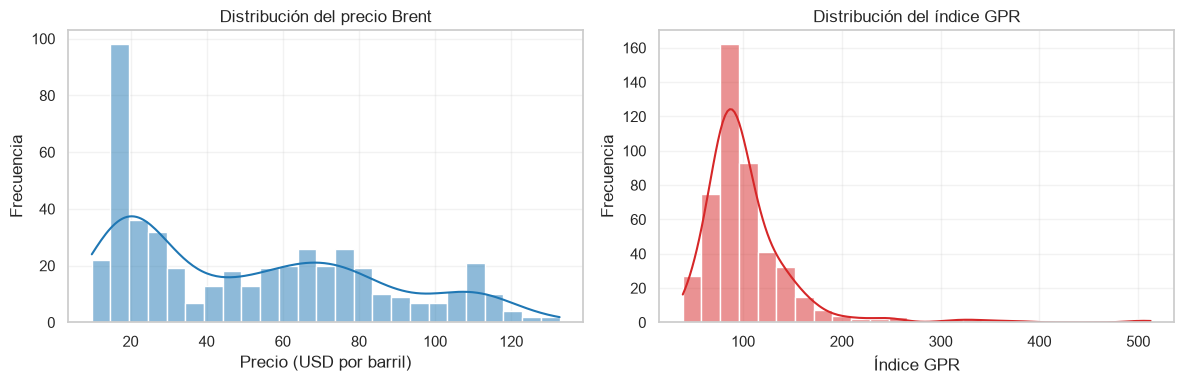

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="brent_price", bins=25, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribución del precio Brent")
axes[0].set_xlabel("Precio (USD por barril)")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(alpha=0.25)

sns.histplot(data=df, x="GPR", bins=25, kde=True, ax=axes[1], color="#d62728")
axes[1].set_title("Distribución del índice GPR")
axes[1].set_xlabel("Índice GPR")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Ambas distribuciones son asimétricas. El GPR concentra muchos meses cerca de sus valores habituales y una cantidad menor de picos elevados.

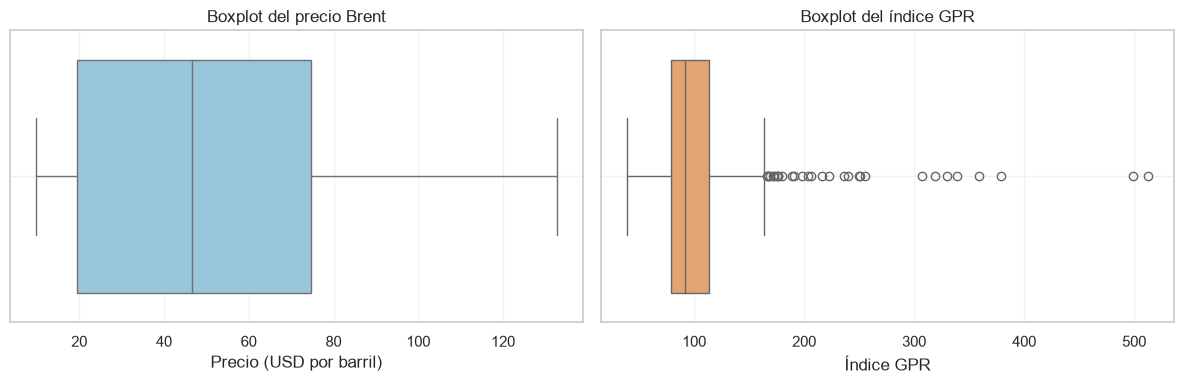

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="brent_price", ax=axes[0], color="#8ecae6")
axes[0].set_title("Boxplot del precio Brent")
axes[0].set_xlabel("Precio (USD por barril)")
axes[0].grid(alpha=0.25)

sns.boxplot(data=df, x="GPR", ax=axes[1], color="#f4a261")
axes[1].set_title("Boxplot del índice GPR")
axes[1].set_xlabel("Índice GPR")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Los boxplots confirman la presencia de valores extremos. Son observaciones reales que deben analizarse, no errores que deban eliminarse.

## 9. Correlaciones entre niveles

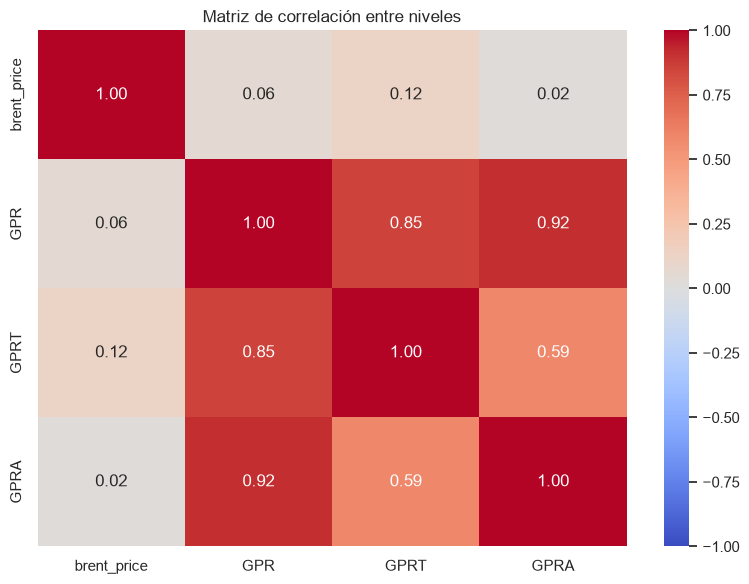

In [12]:
level_columns = [
    "brent_price",
    "GPR",
    "GPRT",
    "GPRA",
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[level_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Matriz de correlación entre niveles")
plt.tight_layout()
plt.show()

La correlación entre el nivel del Brent y el GPR es cercana a cero, por lo que no aparece una relación lineal fuerte durante todo el período. Esto no significa que los conflictos nunca influyan en el precio. `GPR`, `GPRT` y `GPRA` tienen correlaciones altas porque son índices relacionados. Ninguna correlación demuestra causalidad.

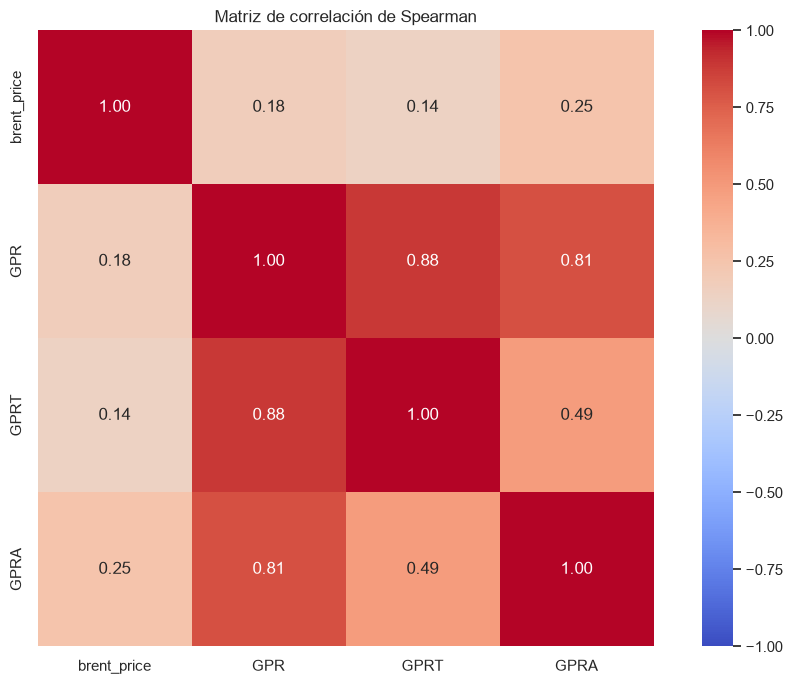

In [13]:
columnas_spearman = [
    "brent_price",
    "GPR",
    "GPRT",
    "GPRA",
]

matriz_spearman = df[columnas_spearman].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(
    matriz_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

Como si es el caso en este análisis, la correlación de Spearman es más adecuada para detectar relaciones no lineales y monotónicas entre las variables. Puede observarse que los analisis efectivos de conflictos geopoliticos a medida q aumentan aumenta el precio del Brent, pero no necesariamente de manera lineal. Esto sugiere que los picos en el riesgo geopolítico pueden tener un impacto significativo en el precio del petróleo, aunque la relación no sea estrictamente proporcional. 

## 10. Variaciones mensuales

Para acercarnos a la hipótesis del proyecto, analizamos si un nivel o un aumento del riesgo se relaciona con cambios posteriores del precio, en lugar de comparar solamente los niveles de ambas series. Lo hacemos mediante Spearman, como mencionamos anteriormente, parece ser que las variaciones siguen una tendencia no lineal, por lo que la correlación de Pearson no es la más adecuada.

In [14]:
df["brent_variation_pct"] = df["brent_price"].pct_change() * 100

df["brent_variation_next_month"] = (
    (df["brent_price_next_month"] / df["brent_price"] - 1) * 100
)

df["GPR_variation"] = df["GPR"].diff()

df[[
    "month",
    "brent_variation_pct",
    "brent_variation_next_month",
    "GPR_variation",
]].head()

,month,brent_variation_pct,brent_variation_next_month,GPR_variation
0,1987-05-01,NaN,1.506997,NaN
1,1987-06-01,1.506997,5.302227,-4.468513
2,1987-07-01,5.302227,-4.431017,4.689560
3,1987-08-01,-4.431017,-3.530032,1.096481
4,1987-09-01,-3.530032,2.457673,21.198631


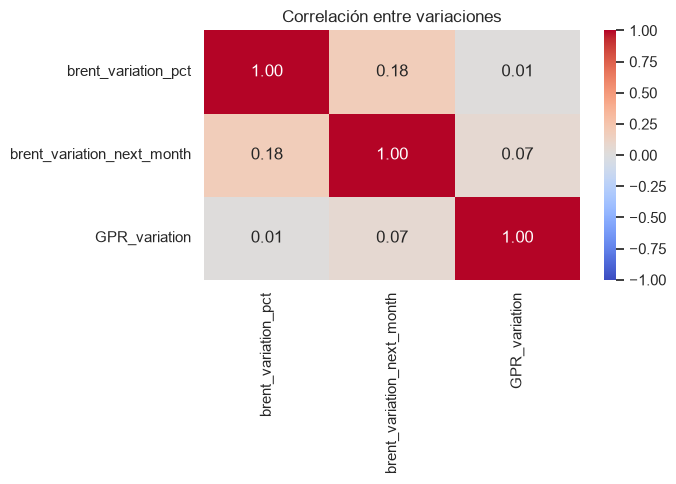

In [15]:
variation_columns = [
    "brent_variation_pct",
    "brent_variation_next_month",
    "GPR_variation",
]

plt.figure(figsize=(7, 5))
sns.heatmap(
    df[variation_columns].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Correlación entre variaciones")
plt.tight_layout()
plt.show()

La correlación de Spearman entre la variación del GPR y la variación del Brent del mes siguiente es 0,07. Esto indica una asociación positiva muy débil en el período analizado.

## 11. Correlación con horizontes de hasta seis meses

,correlacion
Mismo mes,0.007
1 mes,-0.086
2 meses,-0.099
3 meses,-0.090
4 meses,-0.078
5 meses,-0.070
6 meses,-0.069


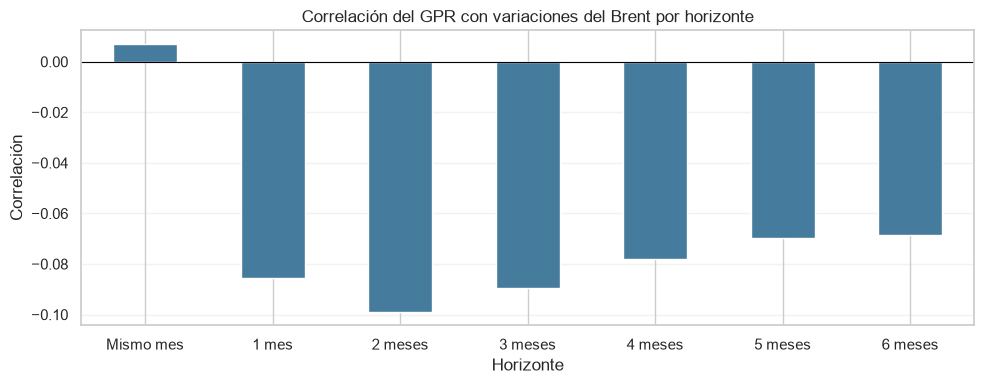

In [16]:
correlaciones_horizonte = {
    "Mismo mes": df["GPR"].corr(df["brent_variation_pct"])
}

for meses in range(1, 7):
    variacion_futura = (
        df["brent_price"].shift(-meses) / df["brent_price"] - 1
    ) * 100
    correlaciones_horizonte[f"{meses} mes" if meses == 1 else f"{meses} meses"] = (
        df["GPR"].corr(variacion_futura)
    )

correlaciones_horizonte = pd.Series(
    correlaciones_horizonte,
    name="correlacion",
)

display(correlaciones_horizonte.round(3).to_frame())

ax = correlaciones_horizonte.plot(
    kind="bar",
    figsize=(10, 4),
    color="#457b9d",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlación del GPR con variaciones del Brent por horizonte")
ax.set_xlabel("Horizonte")
ax.set_ylabel("Correlación")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El efecto de una tensión geopolítica podría no reflejarse exactamente durante el mismo mes. En esta muestra, las correlaciones hasta seis meses continúan siendo pequeñas; el rezago no produce una relación lineal fuerte.

## 12. Meses con riesgo geopolítico alto

In [17]:
umbral = df["GPR"].quantile(0.90)
df["riesgo_geopolitico_alto"] = df["GPR"] >= umbral
df["grupo_riesgo"] = df["riesgo_geopolitico_alto"].map(
    {False: "GPR normal", True: "GPR alto"}
)

resumen_riesgo = (
    df.groupby("grupo_riesgo", observed=True)["brent_variation_next_month"]
    .agg(cantidad="count", media="mean", mediana="median")
    .reindex(["GPR normal", "GPR alto"])
)

print("Umbral del percentil 90:", round(umbral, 2))
display(resumen_riesgo.round(2))

Umbral del percentil 90: 147.08


,cantidad,media,mediana
grupo_riesgo,,,
GPR normal,423,1.01,1.04
GPR alto,48,-0.81,-0.85


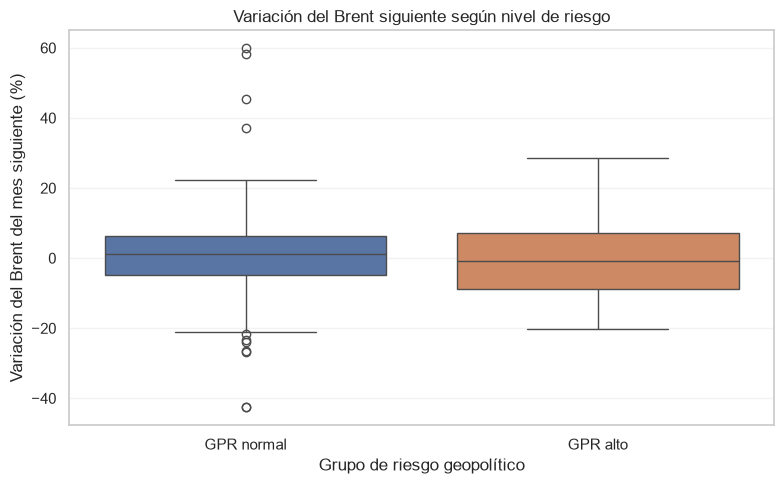

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="grupo_riesgo",
    y="brent_variation_next_month",
    order=["GPR normal", "GPR alto"],
    hue="grupo_riesgo",
    legend=False,
)
plt.title("Variación del Brent siguiente según nivel de riesgo")
plt.xlabel("Grupo de riesgo geopolítico")
plt.ylabel("Variación del Brent del mes siguiente (%)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

El grupo de GPR alto contiene el 10 % de los meses con mayor riesgo. Las distribuciones se superponen y presentan valores positivos y negativos, por lo que no puede afirmarse que el precio siempre suba durante períodos de riesgo elevado.

## 13. Conclusiones iniciales

- La correlación contemporánea entre el nivel del Brent y el GPR es baja, cercana a **0,06**.
- Se observan picos del GPR alrededor de algunos conflictos, pero no todos los movimientos del Brent coinciden con ellos.
- Las relaciones entre variaciones y los horizontes de hasta seis meses también son débiles en esta exploración.
- El precio del petróleo depende además de la producción, el consumo, las decisiones de la OPEP, las reservas y las condiciones económicas.
